# House Price Prediction Using Machine Learning

## Objectives
Objectives of this project are to carry out analysis of housing data and to develop machine learning algorithms to predict the price of a house using certain features like area, number of bedrooms, bathrooms, parking, etc.

In [2]:
#Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Task 1 — Data Loading & Exploration


In [3]:
df = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [32]:
print("Dataset Summary:")
df.describe()

Dataset Summary:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,...,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578,0.141284,0.858716,0.822018,0.177982,...,0.350459,0.954128,0.045872,0.684404,0.315596,0.765138,0.234862,0.256881,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586,0.348635,0.348635,0.382849,0.382849,...,0.477552,0.209399,0.209399,0.465180,0.465180,0.424302,0.424302,0.437314,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (545, 13)
Rows: 545
Columns: 13


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
target = "price"
features = df.drop("price", axis=1).columns
print("Target Column:", target)
print("\nFeature Columns:")
print(features)

Target Column: price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
#No missing values are there but if there are missing values then following code is used:
#num_cols = df.select_dtypes(include=['int64', 'float64']).columns
#for col in num_cols:
#       df[col] = df[col].fillna(df[col].mean())
# or
#df.dropna(inplace=True)

## Task 2 — Data Cleaning

In [10]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


In [11]:
print("Categorical Columns:")
print(df.select_dtypes(include='object').columns)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [12]:
df = pd.get_dummies(df, drop_first=False)

df = df.astype(int)

In [13]:
#verifying data after one-hot encoding
df.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0,1,1,0,...,0,1,0,0,1,0,1,1,0,0
1,12250000,8960,4,4,4,3,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
2,12250000,9960,3,2,2,2,0,1,1,0,...,1,1,0,1,0,0,1,0,1,0
3,12215000,7500,4,2,2,3,0,1,1,0,...,1,1,0,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,0,1,0,1,...,1,1,0,0,1,1,0,1,0,0
5,10850000,7500,3,3,1,2,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
6,10150000,8580,4,3,4,2,0,1,1,0,...,0,1,0,0,1,0,1,0,1,0
7,10150000,16200,5,3,2,0,0,1,1,0,...,0,1,0,1,0,1,0,0,0,1
8,9870000,8100,4,1,2,2,0,1,0,1,...,1,1,0,0,1,0,1,1,0,0
9,9800000,5750,3,2,4,1,0,1,0,1,...,0,1,0,0,1,0,1,0,0,1


In [14]:
print(df.dtypes)

price                              int32
area                               int32
bedrooms                           int32
bathrooms                          int32
stories                            int32
parking                            int32
mainroad_no                        int32
mainroad_yes                       int32
guestroom_no                       int32
guestroom_yes                      int32
basement_no                        int32
basement_yes                       int32
hotwaterheating_no                 int32
hotwaterheating_yes                int32
airconditioning_no                 int32
airconditioning_yes                int32
prefarea_no                        int32
prefarea_yes                       int32
furnishingstatus_furnished         int32
furnishingstatus_semi-furnished    int32
furnishingstatus_unfurnished       int32
dtype: object


In [15]:
print("Final Columns:")
print(df.columns)

Final Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_no', 'mainroad_yes', 'guestroom_no', 'guestroom_yes',
       'basement_no', 'basement_yes', 'hotwaterheating_no',
       'hotwaterheating_yes', 'airconditioning_no', 'airconditioning_yes',
       'prefarea_no', 'prefarea_yes', 'furnishingstatus_furnished',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [16]:
X = df.drop('price', axis=1)
y = df['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 20)
Target Shape: (545,)


## Task 3 — Model Building

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (436, 20)
Testing Set: (109, 20)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [21]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 970043.4039201636
RMSE: 1324506.960091438
R² Score: 0.6529242642153188


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [23]:
y_pred_rf = rf_model.predict(X_test)

In [24]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE : 1004238.7271413597
RMSE: 1388479.6605026398
R² Score: 0.6185876001984603


In [25]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.004239e+06,1.388480e+06,0.618588


In [36]:
predictions = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


### Model Comparison Conclusion
The Linear Regression model performed better compared to the Random Forest Regressor on the current data set due to its higher R² value and reduced error rate. As a result, the Linear Regression model was chosen as the best choice.

## Task 4 — Visualization

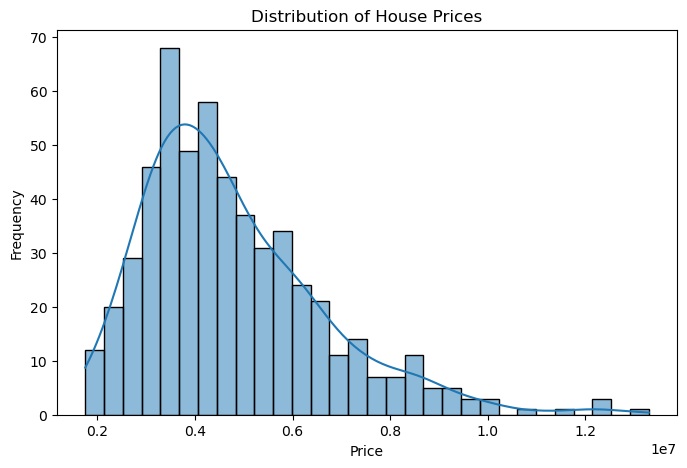

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.savefig('price_distribution.png')

plt.show()

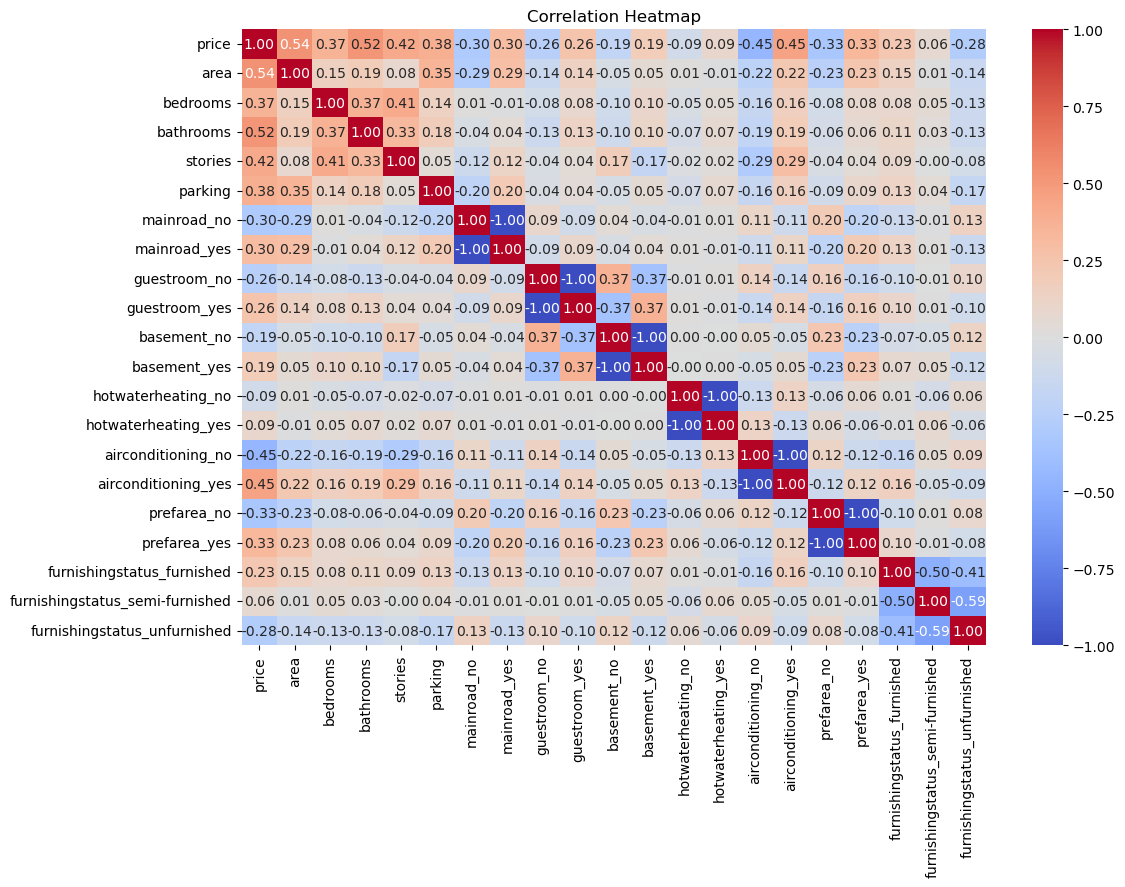

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png')

plt.show()

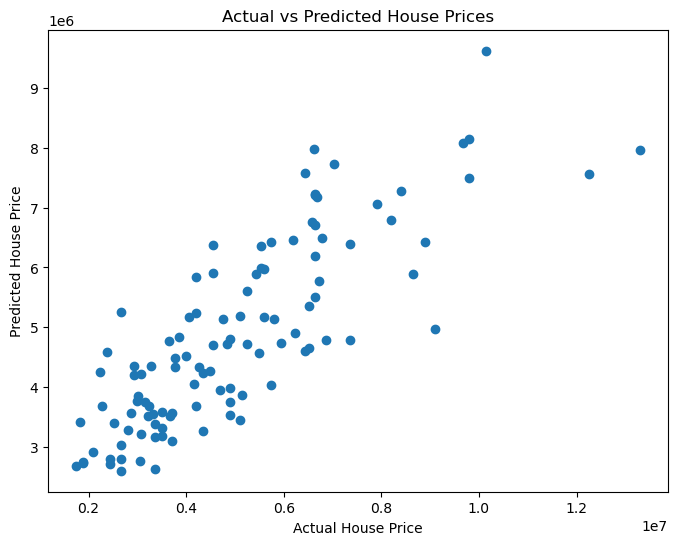

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')

plt.title('Actual vs Predicted House Prices')

plt.savefig('actual_vs_predicted.png')

plt.show()

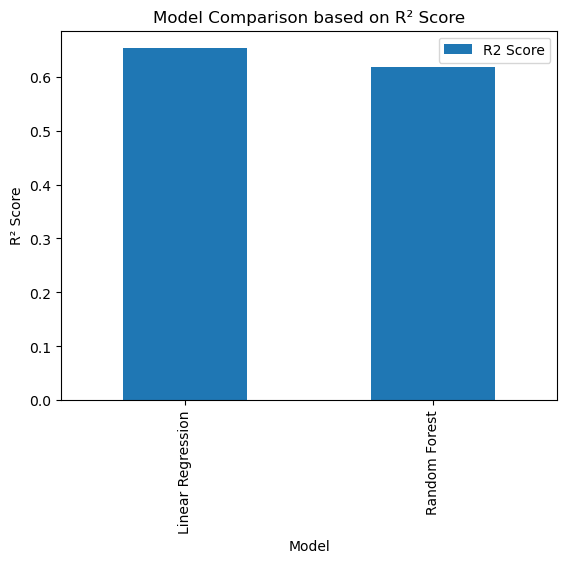

In [40]:
comparison.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    title='Model Comparison based on R² Score'
)

plt.ylabel('R² Score')
plt.savefig('model_comparison.png')
plt.show()

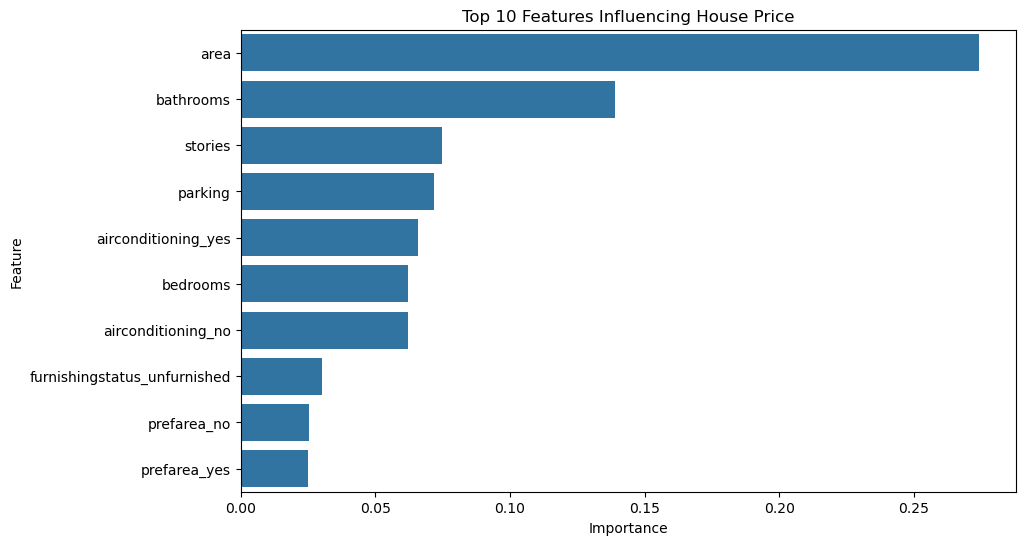

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Features Influencing House Price')
plt.savefig("feature_importance.png")
plt.show()

## Task 5 — Insights & Summary

It was established from the analysis that attributes such as the area, number of bathrooms, parking, and air conditioning affected housing prices the most. 
The R² score of the Linear Regression Model was 0.653. 
In other words, 65.3% of variance in housing prices could be explained by the model. 
In summary, the predictions made using the Linear Regression model were relatively accurate. 
One of the intriguing facts revealed by this study was that amenities such as air conditioning and whether the property was furnished had an effect on the housing prices along with the property size. 
It is interesting to note that Linear Regression outperformed the Random Forest Model in this analysis. 
Therefore, it can be said that real estate businesses need to market their properties by emphasizing larger property size and amenities.